# Stat 451 – Group 12: Spotify Tracks Data Cleaning

**Authors:** Arianna Barbosa, Eirfann Danish Bin Farul Muzri, Mukhriz Hazli Bin Mohamad, Greta Fogel, Levi Hellenbrand, Lexi Rush

**Dataset source:** [Kaggle – Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

---

## Imports

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 120)

## 2. Load the Raw Dataset

In [ ]:
#raw csv file
df_raw = pd.read_csv('dataset.csv')

print(f'Raw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Raw dataset shape: 114,000 rows × 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## FInd out how many nulls

In [ ]:
# Data types and null counts
print('Null Counts')
print(df_raw.isnull().sum())
print()

Null Counts
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64



## 3. Data Cleaning


In [ ]:
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (114000, 21)


### Drop the Unnamed: 0 Column

The Unnamed column is just the numbers of tracks, not important at all. Not informative

In [ ]:
# only run it one time
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f'{df.shape[1]} columns remain')

20 columns remain


### Handle Missing Values

There is exactly 1 row where artists, album_name, and track_name are all null.

In [ ]:
# No imputation cus we cant figure out what is the missing songs/track
df.dropna(inplace=True)
print(f'After dropping nulls: {df.shape[0]:,} rows')

After dropping nulls: 113,999 rows


### Handling Duplicated track_id s

Many tracks appear in multiple rows because the same song is tagged under different genres. example a rock song might appear in alt-rock and once again under rock.

If we leave duplicates in, the model would see the same audio features multiple times, which biases the model toward tracks that happen to belong to many genres.

In [ ]:
before = len(df)
df.drop_duplicates(subset='track_id', keep='first', inplace=True)
after = len(df)
print(f'Removed {before - after:,} duplicate track_id rows')
print(f'Remaining rows: {after:,}')

Removed 24,259 duplicate track_id rows
Remaining rows: 89,740


### Filter Out Non-Music Tracks (Speechiness > 0.66)

According to the documentation:
- speechiness > 0.66 = tracks that are probably made entirely of spoken words (talk shows, audiobooks, poetry)
- speechiness 0.33–0.66 = tracks with both music and speech (e.g., rap)
- speechiness < 0.33 = music and other non-speech tracks

Since our project focuses on predicting the popularity of music, tracks above 0.66 are likely not songs at all. We remove them. We keep the <= 0.66 range because it includes legitimate music genres like rap and hip-hop.

In [ ]:
before = len(df)
high_speech = (df['speechiness'] > 0.66).sum()
print(f'Tracks with speechiness > 0.66: {high_speech}')

df = df[df['speechiness'] <= 0.66]
print(f'Removed {before - len(df):,} word tracks')
print(f'Remaining rows: {len(df):,}')

Tracks with speechiness > 0.66: 868
Removed 868 word tracks
Remaining rows: 88,872


### Remove Zero or Near-Zero Duration Tracks

A track with 0 ms duration is clearly an error

We also remove tracks shorter than 30 seconds (30,000 ms), as these are typically intro clips, sound effects, or metadata artifacts rather than complete songs.

In [ ]:
before = len(df)
print(f'Tracks with duration = 0 ms: {(df["duration_ms"] == 0).sum()}')
print(f'Tracks with duration < 30s: {(df["duration_ms"] < 30000).sum()}')

df = df[df['duration_ms'] >= 30000]
print(f'Removed {before - len(df):,} extremely short tracks')
print(f'Remaining rows: {len(df):,}')

Tracks with duration = 0 ms: 0
Tracks with duration < 30s: 13
Removed 13 extremely short tracks
Remaining rows: 88,859


### Remove Tracks with Zero Tempo

Since tempo is one of our predictive features, keeping rows would just be noises. songs with 0 tempo is just a few so we should still be fine

In [ ]:
before = len(df)
print(f'Tracks with tempo = 0: {(df["tempo"] == 0).sum()}')

df = df[df['tempo'] > 0]
print(f'Removed {before - len(df):,} zero-tempo tracks')
print(f'Remaining rows: {len(df):,}')

Tracks with tempo = 0: 155
Removed 155 zero-tempo tracks
Remaining rows: 88,704


### Converting explicit from Boolean to Integer

Our ML will most likely use 0 or 1, so I am encoding the value from TRUE/FALSE to 1/0.

In [ ]:
df['explicit'] = df['explicit'].astype(int)
print('explicit dtype:', df['explicit'].dtype)
print(df['explicit'].value_counts())

explicit dtype: int32
explicit
0    81534
1     7170
Name: count, dtype: int64


### Convert duration_ms to duration_min

it is just easier to understands

Converting to minutes makes the feature more interpretable. We drop the original duration_ms column afterward.

In [ ]:
df['duration_min'] = df['duration_ms'] / 60000.0
df.drop(columns=['duration_ms'], inplace=True)
print(f'duration_min range: {df["duration_min"].min():.2f} – {df["duration_min"].max():.2f} minutes')

duration_min range: 0.50 – 87.29 minutes


### 4.9 Drop Non-Feature Metadata Columns

The columns track_id, artists, album_name, and track_name are identifiers/metadata. They are not audio features and should NOT be used as predictors in our models:

- track_id is a unique id, no predictive meaning.
- artists and album_name. would cause overfitting and doesn't align with our question (not whether being a famous artist predicts popularity, bias towards famous artist).
- track_name is unique and uninformative for modeling.



In [ ]:
metadata_cols = ['track_id', 'artists', 'album_name', 'track_name']
df.drop(columns=metadata_cols, inplace=True)
print(f'Dropped {metadata_cols}')
print(f'Remaining columns: {list(df.columns)}')

Dropped ['track_id', 'artists', 'album_name', 'track_name']
Remaining columns: ['popularity', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min']


### Reset the Index

After filtering, the DataFrame index has changes. reset the gaps in order. This avoids indexing confusion later.

In [ ]:
df.reset_index(drop=True, inplace=True)
print(f'Index reset. Final shape: {df.shape}')

Index reset. Final shape: (88704, 16)


## Export Cleaned Dataset

USE THIS FOR ALL THE PREDICTIVE MODELLINGS AND ML

In [ ]:
output_path = 'spotify_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset: {output_path}')
print(f'Final clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Cleaned dataset: spotify_cleaned.csv
Final clean shape: 88,704 rows × 16 columns


# Exploratory Data Analysis

In [ ]:
spotify = pd.read_csv("spotify_cleaned.csv")
spotify.head()

,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,73,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,55,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,57,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,71,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,82,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


## Summary statistics


In [ ]:
spotify.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
popularity,88704.0,33.289,20.656,0.000,19.000,34.000,49.000,100.000
explicit,88704.0,0.081,0.273,0.000,0.000,0.000,0.000,1.000
danceability,88704.0,0.563,0.176,0.051,0.450,0.577,0.693,0.985
energy,88704.0,0.635,0.256,0.000,0.457,0.676,0.853,1.000
key,88704.0,5.286,3.561,0.000,2.000,5.000,8.000,11.000
loudness,88704.0,-8.447,5.170,-46.591,-10.252,-7.150,-5.092,4.532
mode,88704.0,0.636,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,88704.0,0.080,0.080,0.022,0.036,0.049,0.084,0.660
acousticness,88704.0,0.324,0.336,0.000,0.017,0.182,0.613,0.996
instrumentalness,88704.0,0.174,0.324,0.000,0.000,0.000,0.100,1.000


###  Popularity Distribution

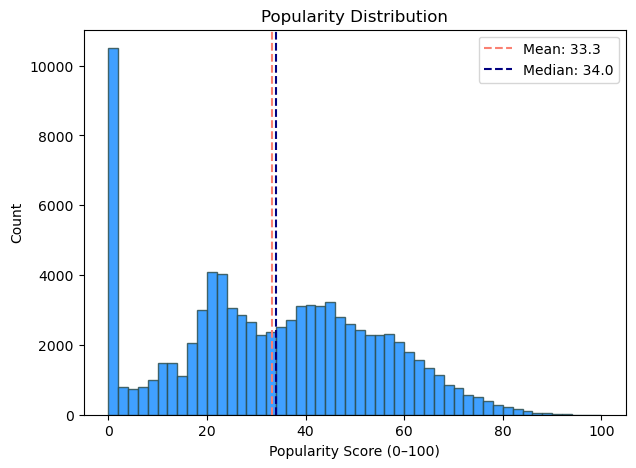

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# histogram of popularity
ax.hist(spotify['popularity'], bins=50, color='dodgerblue', edgecolor='darkslategrey', alpha=0.85)

ax.axvline(spotify['popularity'].mean(), color='salmon', linestyle='--', linewidth=1.5,
           label=f'Mean: {spotify["popularity"].mean():.1f}')

ax.axvline(spotify['popularity'].median(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Median: {spotify["popularity"].median():.1f}')

ax.set_title('Popularity Distribution')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Count')
ax.legend()
plt.show()

In [ ]:
# number of tracks in each popularity point
spotify['popularity'].value_counts()

popularity
0      9420
21     2116
22     2105
20     1966
23     1913
       ... 
97        2
95        2
94        2
100       1
99        1
Name: count, Length: 101, dtype: int64

## Audio Feature Distributions

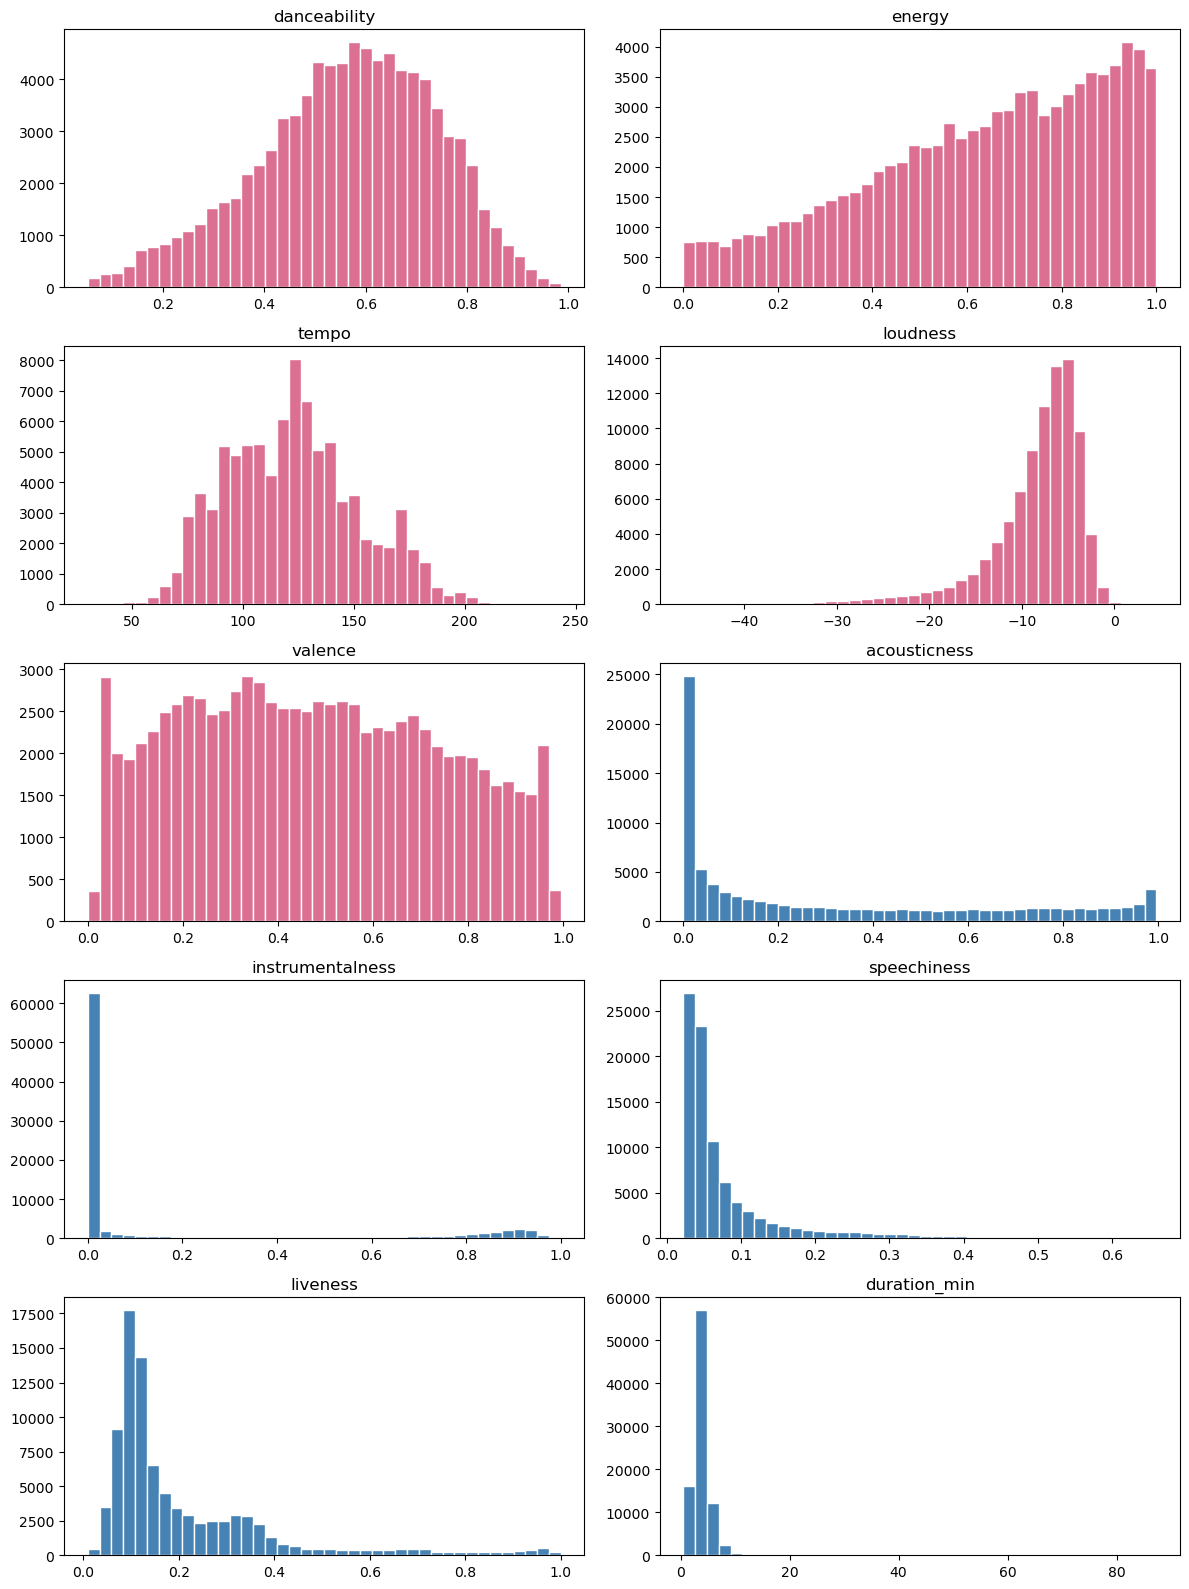

In [ ]:
rythmic = ['danceability', 'energy', 'tempo', 'loudness', 'valence']
acoustic = ['acousticness', 'instrumentalness', 'speechiness', 'liveness']

features = rythmic + acoustic + ['duration_min']

fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(spotify[col].dropna(), bins=40,
                 color='palevioletred' if col in rythmic else 'steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Categorical Feature Distributions

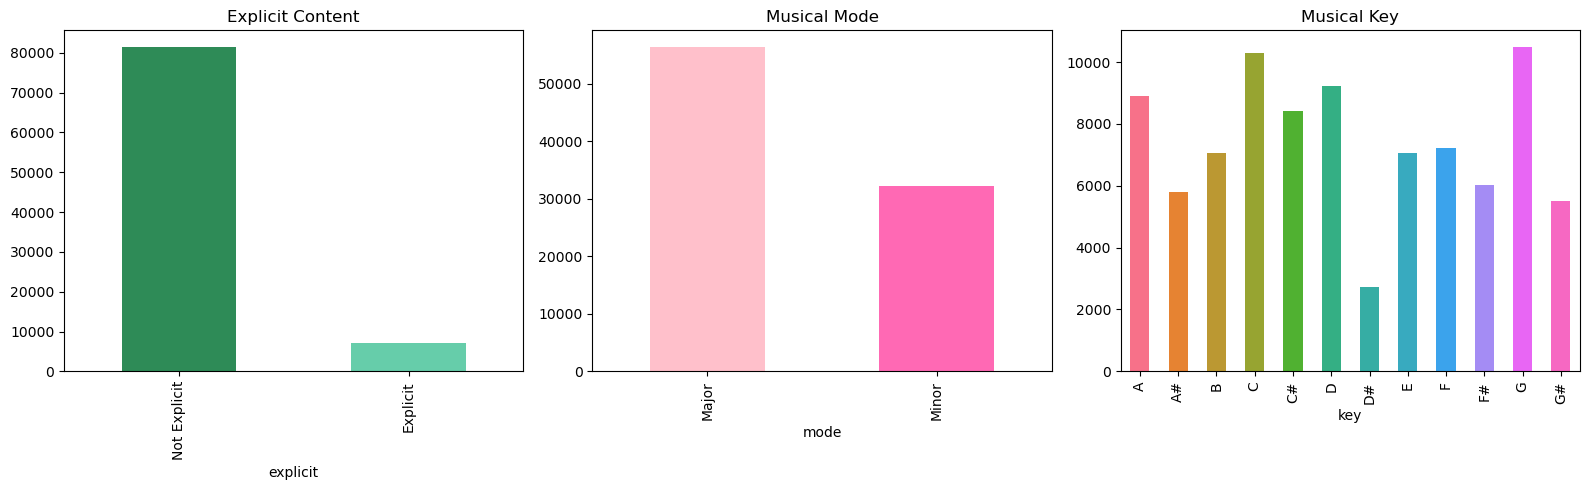

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

spotify['explicit'].replace({0: 'Not Explicit', 1: 'Explicit'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['seagreen', 'mediumaquamarine'])
axes[0].set_title('Explicit Content')

spotify['mode'].replace({0: 'Minor', 1: 'Major'}).value_counts().plot(
    kind='bar', ax=axes[1], color=['pink', 'hotpink'])
axes[1].set_title('Musical Mode')
key_labels = {0:'C',1:'C#',2:'D',3:'D#',4:'E',5:'F', 6:'F#',7:'G',8:'G#',9:'A',10:'A#',11:'B'}

spotify['key'].map(key_labels).value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=sns.color_palette('husl', 12))
axes[2].set_title('Musical Key')

plt.tight_layout()
plt.show()

## Popularity by Genres

Average popularity by Genre

In [ ]:
genre = (spotify.groupby('track_genre')['popularity']
         .agg(['mean', 'median', 'std', 'count'])
         .sort_values('mean', ascending = False)
         .round(2))
genre.columns = ['Mean Popularity', "Median Popularity", "Std Deviation", "Track Count"]

print(f'Total genres: {len(genre)}')
display(genre.head(10))

Total genres: 113


,Mean Popularity,Median Popularity,Std Deviation,Track Count
track_genre,,,,
k-pop,59.42,61.0,12.25,914
pop-film,59.10,60.0,10.74,815
metal,56.42,63.0,19.01,232
chill,53.76,57.0,14.74,968
latino,51.79,46.0,26.06,398
sad,51.11,52.0,12.09,563
grunge,50.59,54.0,14.46,862
indian,49.77,49.0,11.66,733
anime,48.78,50.0,11.72,995


Top & Bottom Genres by Mean Popularity

Text(0.5, 0, 'Mean Popularity')

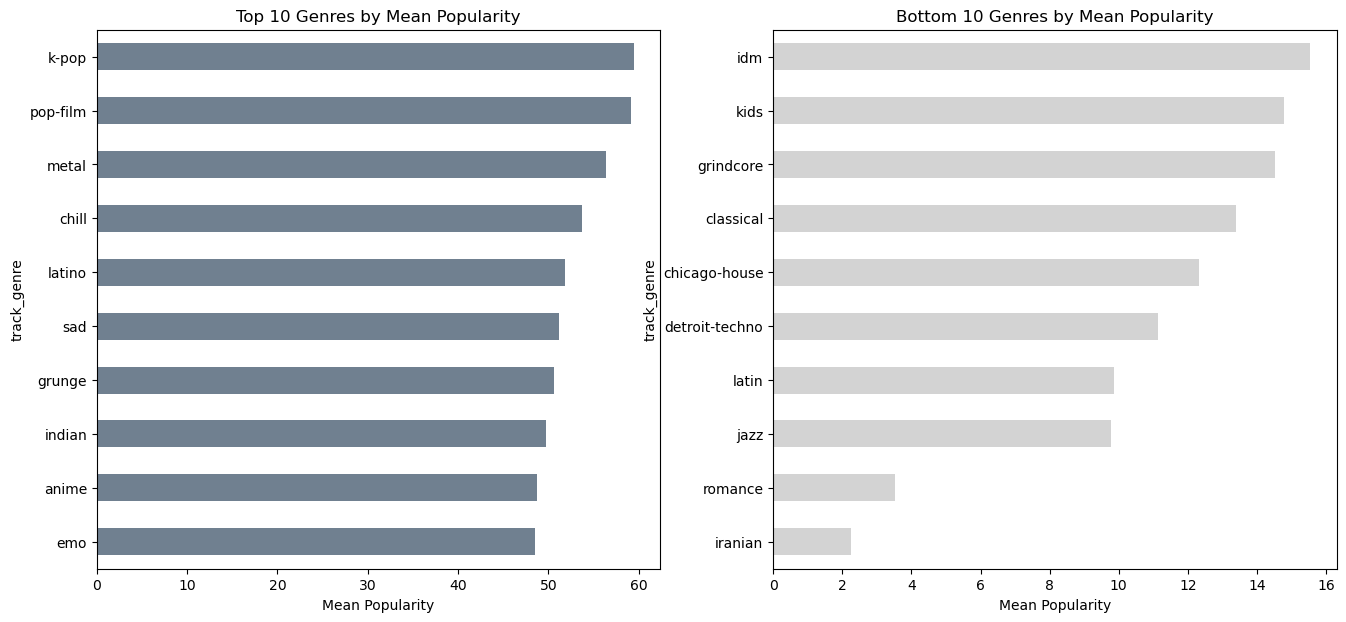

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10 = genre['Mean Popularity'].head(10)
bbottom10 = genre['Mean Popularity'].tail(10)

top10.sort_values().plot(kind='barh', ax=axes[0], color='slategrey')
axes[0].set_title('Top 10 Genres by Mean Popularity')
axes[0].set_xlabel('Mean Popularity')


bbottom10.sort_values().plot(kind='barh', ax=axes[1], color='lightgrey')
axes[1].set_title('Bottom 10 Genres by Mean Popularity')
axes[1].set_xlabel('Mean Popularity')

## Feature Relationships

Correlation Heatmap

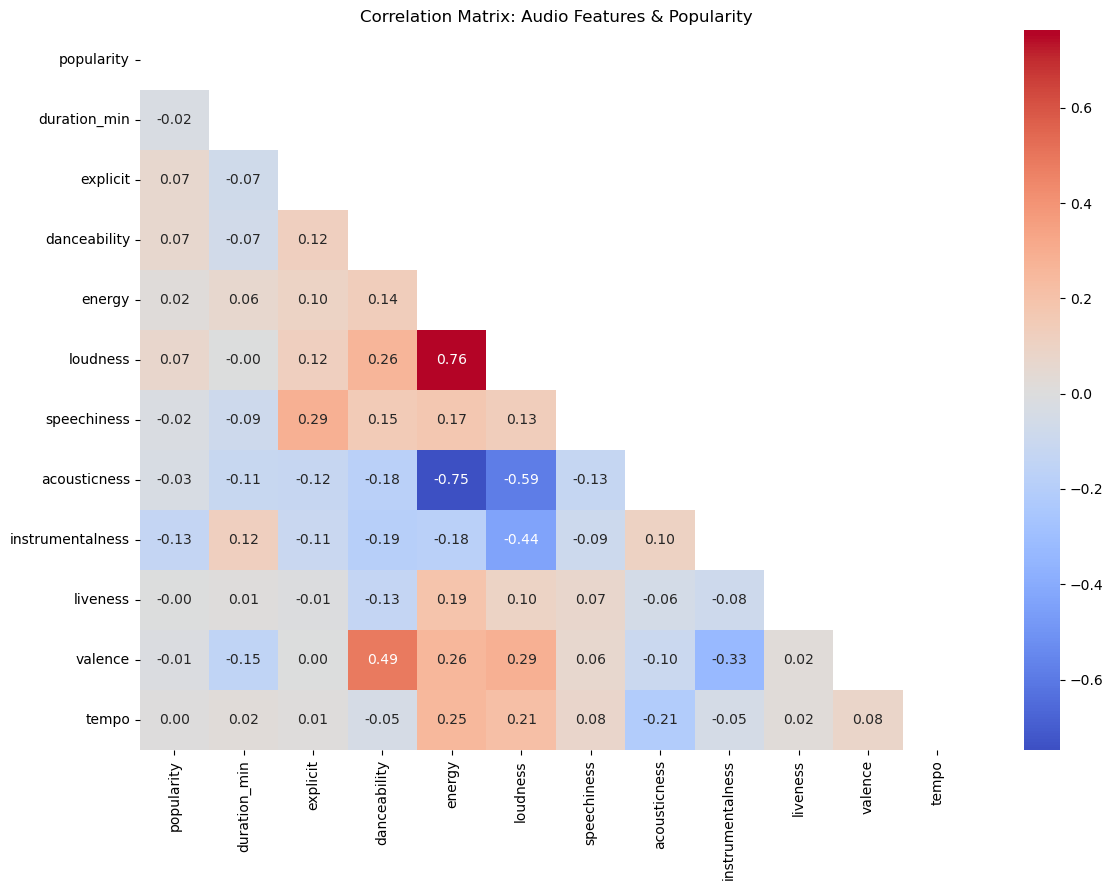

In [ ]:
correlation_columns = [
    'popularity', 'duration_min', 'explicit', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

corr = spotify[correlation_columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 9))
sns.heatmap(corr,mask=mask,
    annot=True,fmt=".2f",cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix: Audio Features & Popularity")
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering for Modeling

In [ ]:
df_model = spotify.copy()
df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

drop_cols = ['duration_ms']  # we use duration_min
string_cols = df_model.select_dtypes(include='object').columns.tolist()
drop_cols += string_cols

df_model = df_model.drop(columns=drop_cols, errors='ignore')

X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]:,}')
print('Feature list (first 20):', X.columns[:20].tolist())



Features: 126  |  Samples: 88,704
Feature list (first 20): ['explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal']


## Creating Train, Validation, and Test Sets

In [ ]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Second split: split temp evenly into validation and final test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test: {X_test.shape[0]:,} rows")

Train: 70,963 rows
Validation: 8,870 rows
Test: 8,871 rows


## Multiple Linear Regression - OLS

In [ ]:
ols_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
ols_pipe.fit(X_train, y_train)
y_pred_ols = ols_pipe.predict(X_val)

ols_r2  = r2_score(y_val, y_pred_ols)
ols_mse = mean_squared_error(y_val, y_pred_ols)
ols_rmse = np.sqrt(ols_mse)

print('=== OLS Multiple Linear Regression ===')
print(f'  R²   : {ols_r2:.4f}')
print(f'  MSE  : {ols_mse:.4f}')
print(f'  RMSE : {ols_rmse:.4f}')

=== OLS Multiple Linear Regression ===
  R²   : 0.3360
  MSE  : 280.0951
  RMSE : 16.7360


## Ridge Regression

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

ridge_params = {'model__alpha': [0.01, 0.1, 1, 10, 100, 500]}
ridge_cv = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train, y_train)

y_pred_ridge = ridge_cv.predict(X_val)
ridge_r2   = r2_score(y_val, y_pred_ridge)
ridge_mse  = mean_squared_error(y_val, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)

print('=== Ridge Regression ===')
print(f'  Best alpha : {ridge_cv.best_params_["model__alpha"]}')
print(f'  R²         : {ridge_r2:.4f}')
print(f'  MSE        : {ridge_mse:.4f}')
print(f'  RMSE       : {ridge_rmse:.4f}')

=== Ridge Regression ===
  Best alpha : 10
  R²         : 0.3359
  MSE        : 280.1030
  RMSE       : 16.7363


## LASSO

In [ ]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(max_iter=10000))
])

lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 50]}
lasso_cv = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train, y_train)

y_pred_lasso = lasso_cv.predict(X_val)
lasso_r2   = r2_score(y_val, y_pred_lasso)
lasso_mse  = mean_squared_error(y_val, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)

lasso_coefs = lasso_cv.best_estimator_.named_steps['model'].coef_
n_zeroed = (lasso_coefs == 0).sum()

print('=== Lasso Regression ===')
print(f'  Best alpha         : {lasso_cv.best_params_["model__alpha"]}')
print(f'  R²                 : {lasso_r2:.4f}')
print(f'  MSE                : {lasso_mse:.4f}')
print(f'  RMSE               : {lasso_rmse:.4f}')
print(f'  Features zeroed out: {n_zeroed} / {len(lasso_coefs)}')

=== Lasso Regression ===
  Best alpha         : 0.001
  R²                 : 0.3359
  MSE                : 280.1291
  RMSE               : 16.7371
  Features zeroed out: 0 / 126


## DT Regressor

In [ ]:
dt_params = {
    'max_depth':        [3, 5, 8, 10, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'min_samples_split':[10, 20, 50]
}
dt_cv = GridSearchCV(DecisionTreeRegressor(random_state=42),
                     dt_params, cv=5, scoring='r2', n_jobs=-1)
dt_cv.fit(X_train, y_train)

y_pred_dt = dt_cv.predict(X_val)
dt_r2   = r2_score(y_val, y_pred_dt)
dt_mse  = mean_squared_error(y_val, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)

print('=== Decision Tree Regressor ===')
print(f'  Best params : {dt_cv.best_params_}')
print(f'  R²          : {dt_r2:.4f}')
print(f'  MSE         : {dt_mse:.4f}')
print(f'  RMSE        : {dt_rmse:.4f}')

=== Decision Tree Regressor ===
  Best params : {'max_depth': None, 'min_samples_leaf': 50, 'min_samples_split': 10}
  R²          : 0.3353
  MSE         : 280.3545
  RMSE        : 16.7438


## Comparing models

,R²,MSE,RMSE
Model,,,
OLS Linear,0.3360,280.0951,16.7360
Ridge,0.3359,280.1030,16.7363
Lasso,0.3359,280.1291,16.7371
Decision Tree,0.3353,280.3545,16.7438


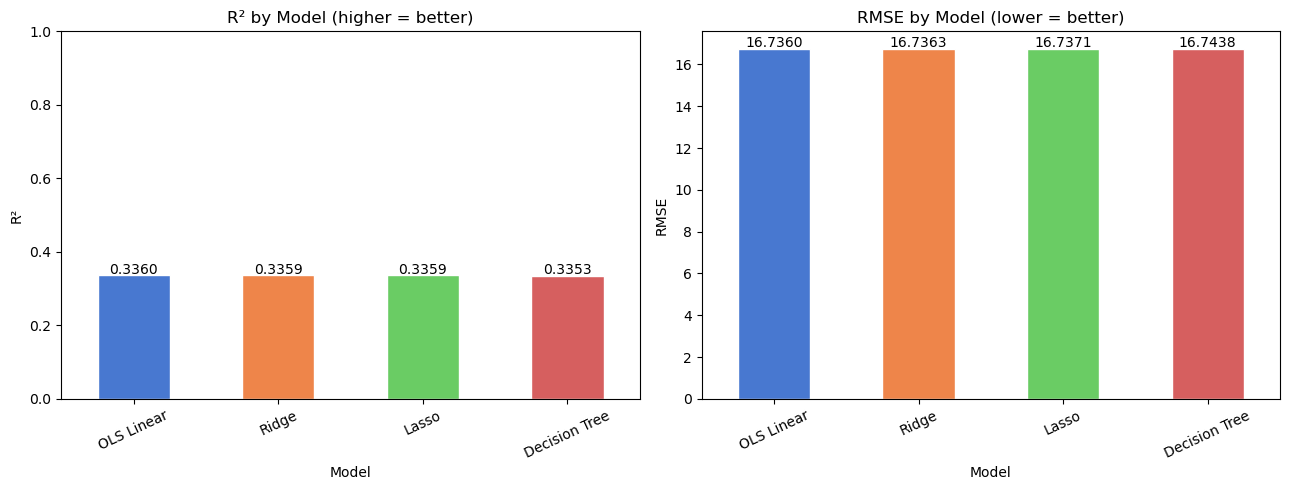

In [ ]:
results = pd.DataFrame({
    'Model': ['OLS Linear', 'Ridge', 'Lasso', 'Decision Tree'],
    'R²':    [ols_r2,  ridge_r2,  lasso_r2,  dt_r2],
    'MSE':   [ols_mse, ridge_mse, lasso_mse, dt_mse],
    'RMSE':  [ols_rmse,ridge_rmse,lasso_rmse,dt_rmse]
}).set_index('Model').round(4)

display(results)

# visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results['R²'].plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', 4),
                   edgecolor='white')
axes[0].set_title('R² by Model (higher = better)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=25)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.005),
                     ha='center', fontsize=10)

results['RMSE'].plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', 4),
                     edgecolor='white')
axes[1].set_title('RMSE by Model (lower = better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.1),
                     ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Extract core audio feature names (exclude genre dummies)
audio_features = ['duration_min', 'explicit', 'danceability', 'energy', 'key',
                  'loudness', 'mode', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
audio_idx = [list(X.columns).index(f) for f in audio_features if f in X.columns]

ols_coefs   = ols_pipe.named_steps['model'].coef_[audio_idx]
ridge_coefs = ridge_cv.best_estimator_.named_steps['model'].coef_[audio_idx]
lasso_coefs_audio = lasso_cv.best_estimator_.named_steps['model'].coef_[audio_idx]

coef_df = pd.DataFrame({
    'Feature': audio_features,
    'OLS':     ols_coefs,
    'Ridge':   ridge_coefs,
    'Lasso':   lasso_coefs_audio
}).set_index('Feature').round(4)

display(coef_df)

,OLS,Ridge,Lasso
Feature,,,
duration_min,-0.0552,-0.0554,-0.0545
explicit,0.5950,0.5949,0.5940
danceability,0.9010,0.9007,0.8987
energy,-0.6087,-0.6101,-0.6094
key,-0.0742,-0.0742,-0.0730
loudness,0.2802,0.2812,0.2801
mode,-0.4194,-0.4189,-0.4164
speechiness,-0.3070,-0.3076,-0.3088
acousticness,-0.5963,-0.5949,-0.5873


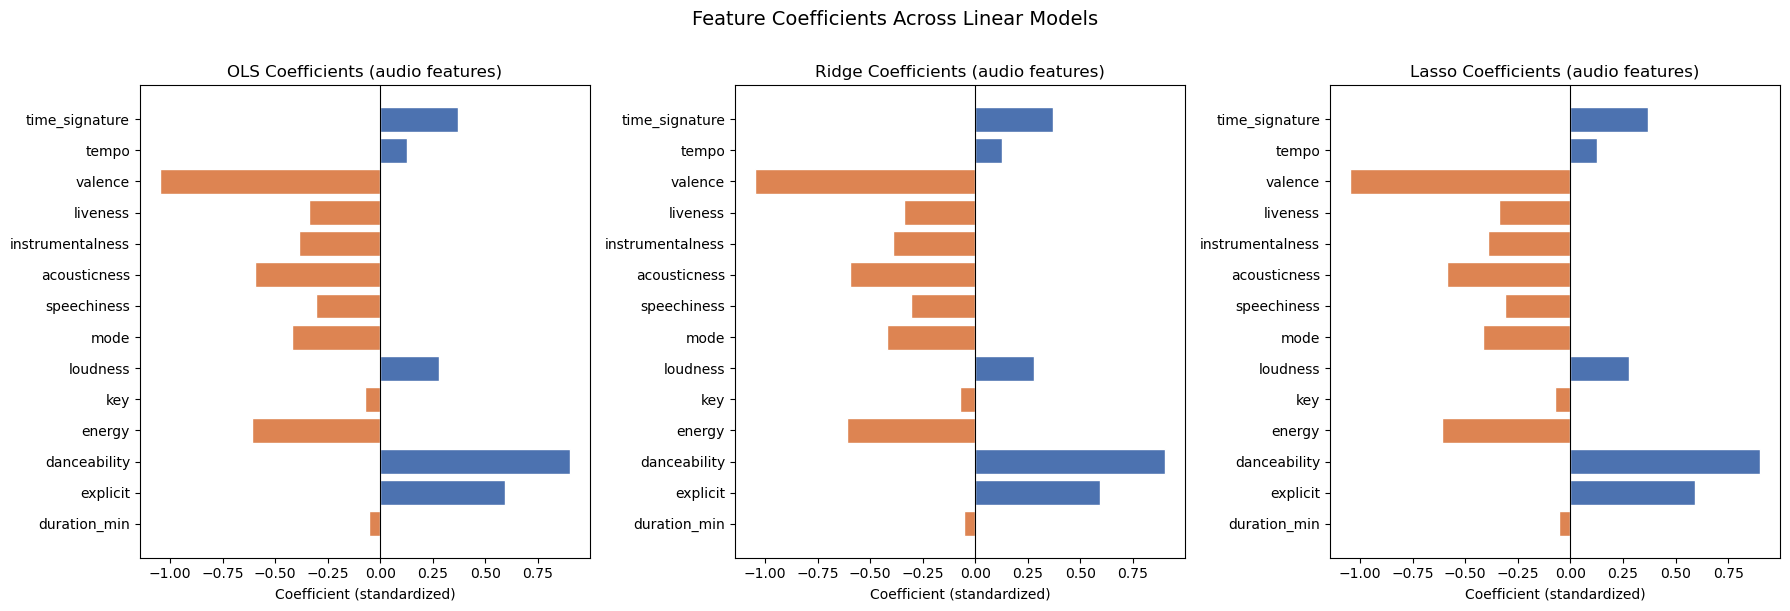

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name, coefs in zip(axes, ['OLS', 'Ridge', 'Lasso'],
                           [ols_coefs, ridge_coefs, lasso_coefs_audio]):
    colors = ['#4C72B0' if c >= 0 else '#DD8452' for c in coefs]
    ax.barh(audio_features, coefs, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} Coefficients (audio features)')
    ax.set_xlabel('Coefficient (standardized)')

plt.suptitle('Feature Coefficients Across Linear Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

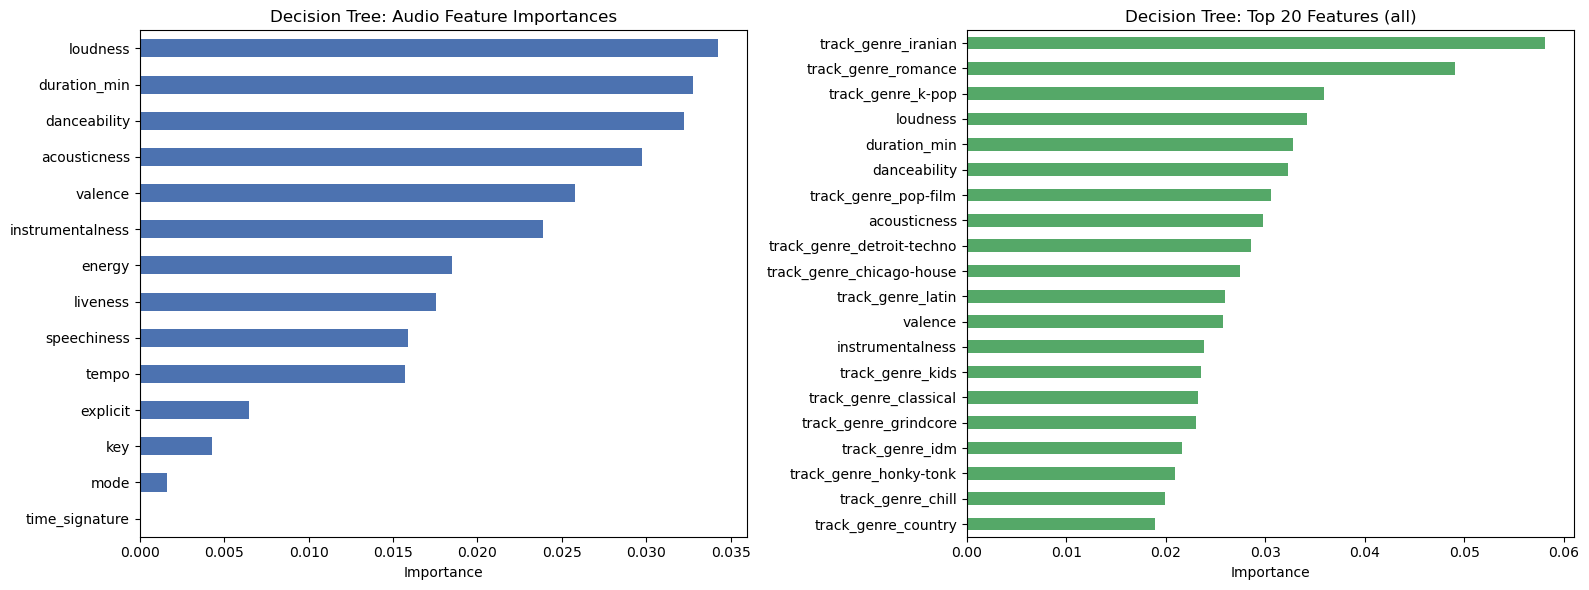

In [ ]:
importances = pd.Series(
    dt_cv.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Audio features only
imp_audio = importances[[f for f in audio_features if f in importances.index]]
# Top 20 overall (includes genre dummies)
imp_top20 = importances.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_audio.sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Decision Tree: Audio Feature Importances')
axes[0].set_xlabel('Importance')

imp_top20.sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Decision Tree: Top 20 Features (all)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Applying Best Model to Test Set

In [ ]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

ols_pipe.fit(X_train_full, y_train_full)

y_pred_test = ols_pipe.predict(X_test)

test_r2 = r2_score(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

print('=== FINAL TEST PERFORMANCE (OLS) ===')
print(f'  R²   : {test_r2:.4f}')
print(f'  MSE  : {test_mse:.4f}')
print(f'  RMSE : {test_rmse:.4f}')

=== FINAL TEST PERFORMANCE (OLS) ===
  R²   : 0.3516
  MSE  : 273.2665
  RMSE : 16.5308
